In [45]:
# Q1: Detect and remove duplicates
dup_count = df.duplicated().sum()
print(f"Duplicates found: {dup_count}")

if dup_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicates found.")


Duplicates found: 0
No duplicates found.


In [46]:
# Q2: Handle missing values
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Missing values BEFORE:")
display(df.isna().sum())

# Fill numeric columns with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode (or "Unknown")
for col in cat_cols:
    mode_vals = df[col].mode(dropna=True)
    fill_val = mode_vals.iloc[0] if not mode_vals.empty else "Unknown"
    df[col] = df[col].fillna(fill_val)

print("Missing values AFTER:")
display(df.isna().sum())


Missing values BEFORE:


,0
id,0
size_sqft,0
bedrooms,0
bathrooms,0
location,0
house_type,0
year_built,0
date_sold,0
price,0


Missing values AFTER:


,0
id,0
size_sqft,0
bedrooms,0
bathrooms,0
location,0
house_type,0
year_built,0
date_sold,0
price,0


In [47]:
# Q3: Detect outliers using Z-score (>3) and apply Winsorization
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if num_cols:
    z = np.abs(stats.zscore(df[num_cols], nan_policy="omit"))
    z = pd.DataFrame(z, columns=num_cols, index=df.index)
    outlier_counts = (z > 3).sum()
    print("Outlier counts (Z > 3):")
    display(outlier_counts)

    # Winsorization (cap extreme values at 1% and 99%)
    for col in num_cols:
        lo, hi = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(lower=lo, upper=hi)

    print("Winsorization applied.")


Outlier counts (Z > 3):


,0
id,0
size_sqft,4
bedrooms,3
bathrooms,3
year_built,5
price,4


Winsorization applied.


In [48]:
# Q1: Z-score standardization for Size(sqft) and Price
for col in ["size_sqft", "price"]:
    if col in df.columns:
        mu, sigma = df[col].mean(), df[col].std(ddof=0)
        df[col + "_z"] = (df[col] - mu) / (sigma if sigma != 0 else 1)
        print(f"{col} standardized (mean≈0, std≈1).")


size_sqft standardized (mean≈0, std≈1).
price standardized (mean≈0, std≈1).


In [49]:
# Q2: Mean normalization for Bedrooms and Bathrooms
for col in ["bedrooms", "bathrooms"]:
    if col in df.columns:
        mu = df[col].mean()
        df[col + "_mean_norm"] = df[col] - mu
        print(f"{col} mean-normalized (mean=0).")


bedrooms mean-normalized (mean=0).
bathrooms mean-normalized (mean=0).


In [50]:
# Q3: Min-Max scaling for Year Built
if "year_built" in df.columns:
    scaler = MinMaxScaler()
    df["year_built_minmax"] = scaler.fit_transform(df[["year_built"]])
    print("Year Built scaled to [0,1].")


Year Built scaled to [0,1].


In [51]:
### Project 3

# Q1: Label encode Location
if "location" in df.columns:
    cats = df["location"].astype("category")
    df["location_label"] = cats.cat.codes
    print("Label encoding applied to 'location'. Mapping preview:")
    display(pd.DataFrame({"location": cats.cat.categories, "code": range(len(cats.cat.categories))}).head(10))


Label encoding applied to 'location'. Mapping preview:


,location,code
0,Rural,0
1,Suburban,1
2,Urban,2


from matplotlib import pyplot as plt
_df_91['code'].plot(kind='hist', bins=20, title='code')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_92.groupby('location').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['code']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'code'}, axis=1)
              .sort_values('code', ascending=True))
  xs = counted['code']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_93.sort_values('code', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('location')):
  _plot_series(series, series_name, i)
  fig.legend(title='location', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('code')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_94['code'].plot(kind='line', figsize=(8, 4), title='code')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_95['location'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_95, x='code', y='location', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [52]:
# Q2: One-hot encode House_Type
if "house_type" in df.columns:
    dummies = pd.get_dummies(df["house_type"], prefix="house_type")
    df = pd.concat([df.drop(columns=["house_type"]), dummies], axis=1)
    print("One-hot encoding applied to 'house_type'. New columns:")
    print(list(dummies.columns))


One-hot encoding applied to 'house_type'. New columns:
['house_type_-44945700', 'house_type_168148', 'house_type_275203', 'house_type_339629', 'house_type_484681', 'house_type_517113', 'house_type_627035', 'house_type_655839', 'house_type_665894', 'house_type_74416700', 'house_type_748531', 'house_type_Apartment', 'house_type_Detached', 'house_type_Semi-Detached', 'house_type_Townhouse']


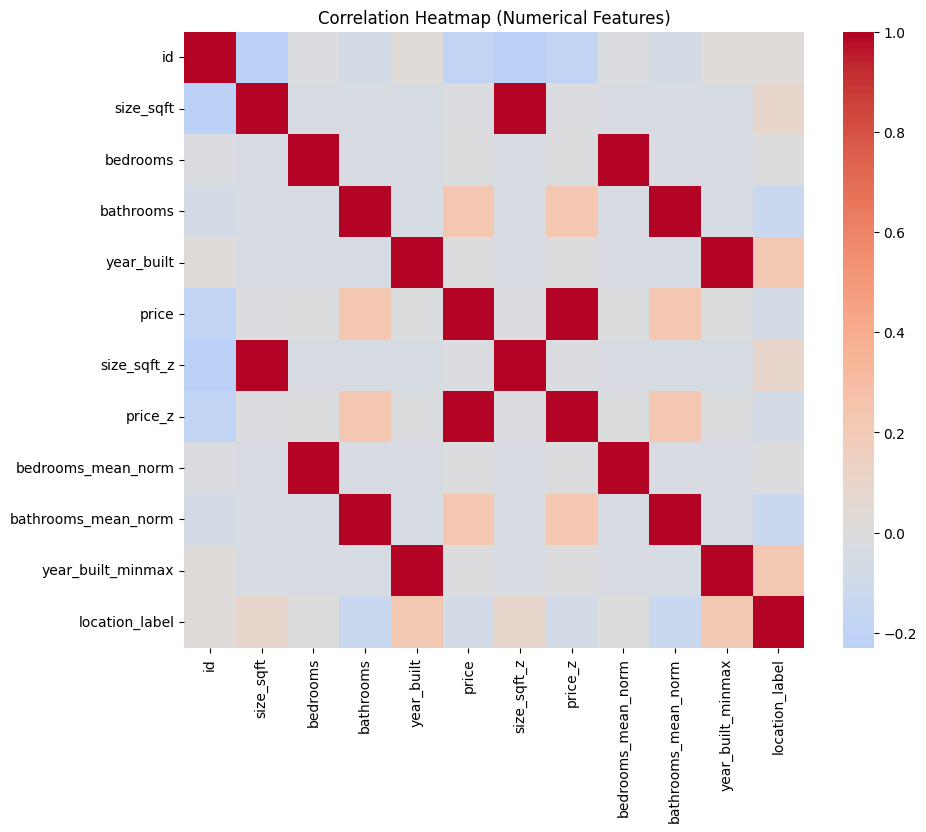

In [53]:
# Q1: Correlation heatmap
num_cols_proc = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols_proc].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


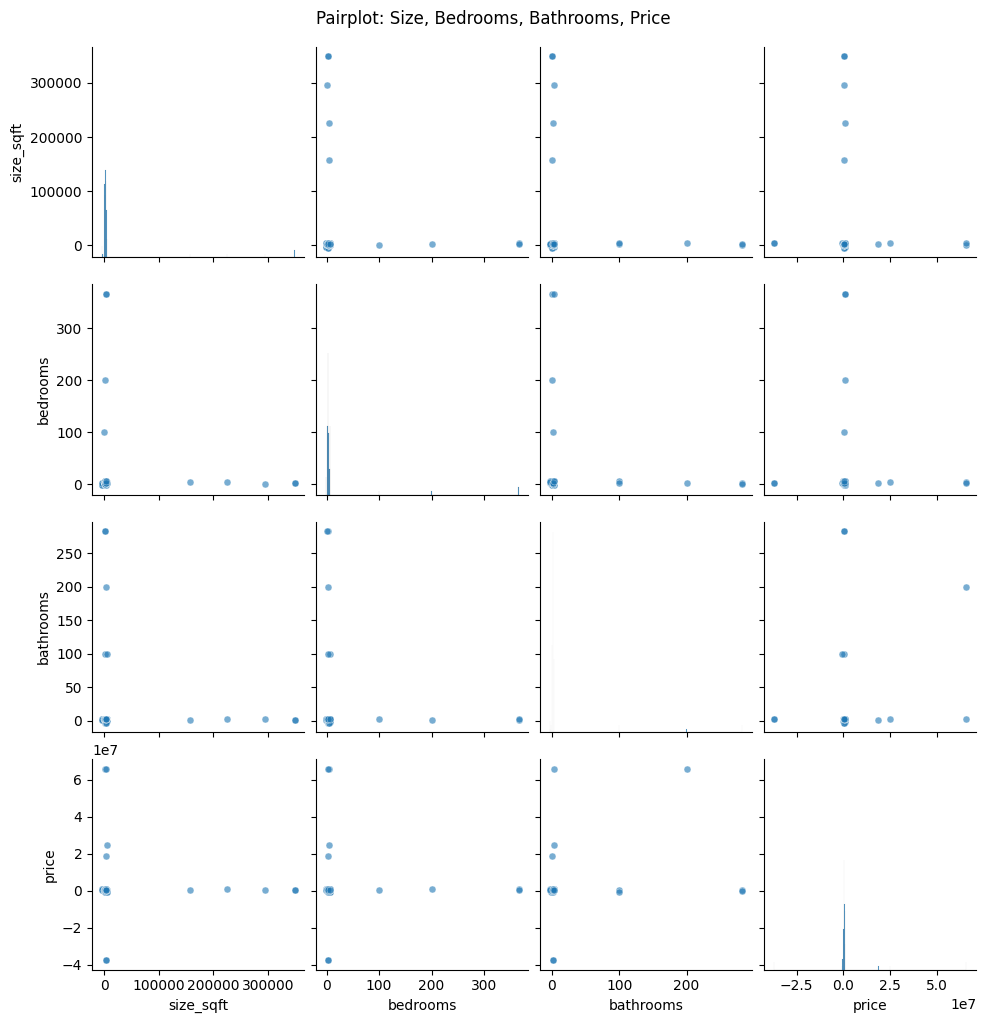

In [54]:
# Q2: Pairplot of Size, Bedrooms, Bathrooms, Price
pair_cols = [c for c in ["size_sqft", "bedrooms", "bathrooms", "price"] if c in df.columns]
if len(pair_cols) >= 2:
    sample = df[pair_cols]
    if len(sample) > 1000:
        sample = sample.sample(1000, random_state=42)  # subsample for speed
    sns.pairplot(sample, diag_kind="hist", plot_kws={"alpha":0.6, "s":25})
    plt.suptitle("Pairplot: Size, Bedrooms, Bathrooms, Price", y=1.02)
    plt.show()


In [55]:
# Q1: Create new features
created = []

if {"price", "size_sqft"}.issubset(df.columns):
    df["price_per_sqft"] = df["price"] / df["size_sqft"].replace(0, np.nan)
    df["price_per_sqft"] = df["price_per_sqft"].fillna(df["price_per_sqft"].median())
    created.append("price_per_sqft")

if "year_built" in df.columns:
    df["age_of_house"] = pd.Timestamp.today().year - df["year_built"]
    created.append("age_of_house")

if {"bedrooms", "bathrooms"}.issubset(df.columns):
    df["beds_baths_ratio"] = df["bedrooms"] / df["bathrooms"].replace(0, np.nan)
    df["beds_baths_ratio"] = df["beds_baths_ratio"].fillna(df["beds_baths_ratio"].median())
    created.append("beds_baths_ratio")

if {"size_sqft", "bedrooms"}.issubset(df.columns):
    df["size_per_bedroom"] = df["size_sqft"] / df["bedrooms"].replace(0, np.nan)
    df["size_per_bedroom"] = df["size_per_bedroom"].fillna(df["size_per_bedroom"].median())
    created.append("size_per_bedroom")

print("New features created:", created)
display(df[created].head(10))


New features created: ['price_per_sqft', 'age_of_house', 'beds_baths_ratio', 'size_per_bedroom']


,price_per_sqft,age_of_house,beds_baths_ratio,size_per_bedroom
0,265.182796,87.00,0.500000,837.000000
1,559.619013,-195248.39,1.000000,1378.000000
2,1.471650,73.00,4.000000,39400.000000
3,-107.331471,84.00,3.000000,-1446.726967
4,408.621160,76.00,2.000000,146.500000
5,66444.985726,87.00,1.666667,198.400000
6,82.071819,112.00,3.000000,854.000000
7,189.822080,31.00,365.620000,11.990591
8,274.620567,4.00,2.000000,141.000000
9,77.358866,121.00,1.500000,1022.666667


from matplotlib import pyplot as plt
_df_96['price_per_sqft'].plot(kind='hist', bins=20, title='price_per_sqft')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_97['age_of_house'].plot(kind='hist', bins=20, title='age_of_house')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_98['beds_baths_ratio'].plot(kind='hist', bins=20, title='beds_baths_ratio')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_102.plot(kind='scatter', x='beds_baths_ratio', y='size_per_bedroom', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_103['price_per_sqft'].plot(kind='line', figsize=(8, 4), title='price_per_sqft')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_104['age_of_house'].plot(kind='line', figsize=(8, 4), title='age_of_house')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_105['beds_baths_ratio'].plot(kind='line', figsize=(8, 4), title='beds_baths_ratio')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_106['size_per_bedroom'].plot(kind='line', figsize=(8, 4), title='size_per_bedroom')
plt.gca().spines[['top', 'right']].set_visible(False)